# Full Naive Bayes Classification Pipeline (Play Tennis Dataset)

## Importing libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pandas helps us load and handle data

LabelEncoder is used to convert text (like “Sunny”) into numbers

CategoricalNB is the Naive Bayes algorithm for categorical features

train_test_split divides our data into training/testing sets

Metrics help us evaluate our model

## Load Dataset

In [69]:
# Creating the Play Tennis Dataset
data = {
    "Outlook": ["Sunny", "Sunny", "Overcast", "Rainy", "Rainy", "Rainy", "Overcast",
                "Sunny", "Sunny", "Rainy", "Sunny", "Overcast", "Overcast", "Rainy"],
    "Temperature": ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool",
                    "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "Play": ["No", "No", "Yes", "Yes", "Yes", "No", "Yes",
             "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"]
}

df = pd.DataFrame(data)
df.head()

,Outlook,Temperature,Play
0,Sunny,Hot,No
1,Sunny,Hot,No
2,Overcast,Hot,Yes
3,Rainy,Mild,Yes
4,Rainy,Cool,Yes


Explanation: We’re creating a simple dataset with 3 columns:

- Outlook and Temperature = input features

- Play = target variable (whether we play or not)



##  Understand the Data (EDA)

### Check dataset shape and basic info

In [13]:
print("Shape of dataset:", df.shape)

Shape of dataset: (14, 3)


In [15]:
print("\nData types:")
print(df.dtypes)


Data types:
Outlook        object
Temperature    object
Play           object
dtype: object


### Count of classes

In [18]:
print("\nPlay column value counts:")
print(df['Play'].value_counts())


Play column value counts:
Play
Yes    9
No     5
Name: count, dtype: int64


 Explanation:

- Always check your data size, types, and balance between labels.

- We want to see if “Yes” and “No” are balanced.

### Visualize class distribution

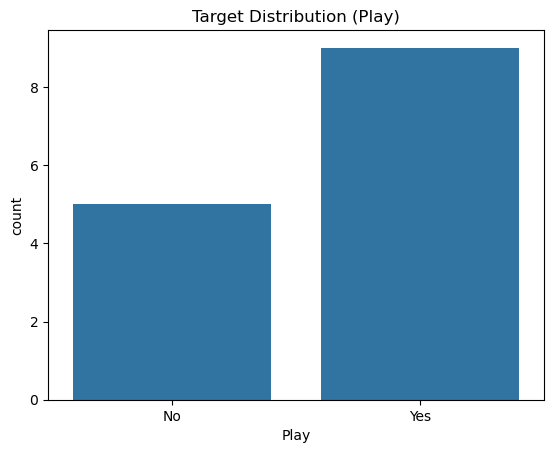

In [73]:
sns.countplot(data=df, x='Play')
plt.title("Target Distribution (Play)")
plt.show()

- This bar chart helps us visualize class balance.

- If data is too imbalanced, the model can be biased.

## Visualize Relationships

In [24]:
# Crosstab for better understanding
print(pd.crosstab(df['Outlook'], df['Play']))
print(pd.crosstab(df['Temperature'], df['Play']))

Play      No  Yes
Outlook          
Overcast   0    4
Rainy      2    3
Sunny      3    2
Play         No  Yes
Temperature         
Cool          1    3
Hot           2    2
Mild          2    4


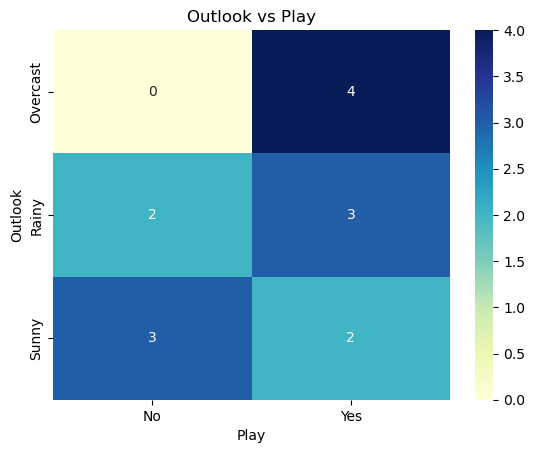

In [26]:
# Heatmap
sns.heatmap(pd.crosstab(df['Outlook'], df['Play']), annot=True, cmap='YlGnBu')
plt.title("Outlook vs Play")
plt.show()

- We use crosstabs to see how categories in one column relate to the target.

- Example: How many times was “Play=Yes” when “Outlook=Sunny”?

## Label Encoding (Turn Text to Numbers)

In [30]:
df.head()

,Outlook,Temperature,Play
0,Sunny,Hot,No
1,Sunny,Hot,No
2,Overcast,Hot,Yes
3,Rainy,Mild,Yes
4,Rainy,Cool,Yes


In [32]:
# Convert categorical columns to numeric using LabelEncoder
le = LabelEncoder()

df['Outlook'] = le.fit_transform(df['Outlook'])     # Sunny = 2, Overcast = 0, Rainy = 1 (example)
df['Temperature'] = le.fit_transform(df['Temperature'])  # Cool = 0, Hot = 1, Mild = 2
df['Play'] = le.fit_transform(df['Play'])           # No = 0, Yes = 1

df.head()

,Outlook,Temperature,Play
0,2,1,0
1,2,1,0
2,0,1,1
3,1,2,1
4,1,0,1


- ML models can’t work with text – we convert to numbers.

- LabelEncoder does this automatically.

## Feature & Target Split + Train/Test Split

In [35]:
# Split features and target
X = df[['Outlook', 'Temperature']]
y = df['Play']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


We're telling the model: Use Outlook + Temperature to predict Play
We split the data to test the model on unseen data.

stratify=y keeps class balance in both train and test.

## Train Naive Bayes Model

In [38]:
# Train the Naive Bayes model
model = CategoricalNB()
model.fit(X_train, y_train)

CategoricalNB()

Naive Bayes is good for categorical and small datasets.

We train the model on training data.

## Evaluate Model

In [55]:
# Predict on test data
y_pred = model.predict(X_test)

### Accuracy

In [58]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8000


### Confusion Matrix

In [48]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1 1]
 [0 3]]


### Classification Report

In [51]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



Accuracy: overall correctness

Confusion Matrix: breakdown of predictions

Classification Report: shows precision, recall, f1-score

## Visualize Confusion Matrix

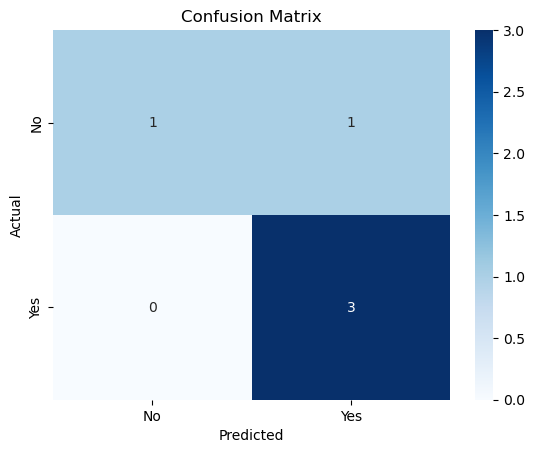

In [61]:
# Visualize the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Predict on a New Example

In [92]:
# Predict for a new sample: Outlook=Sunny, Temperature=Cool
sample = pd.DataFrame([[2, 1]], columns=['Outlook', 'Temperature'])  # Sunny=2, hot=1
prediction = model.predict(sample)
print("Prediction for (Sunny, hot) ➡", "Yes" if prediction[0] == 1 else "No")


Prediction for (Sunny, hot) ➡ No


# Extra info if you want to dive deep

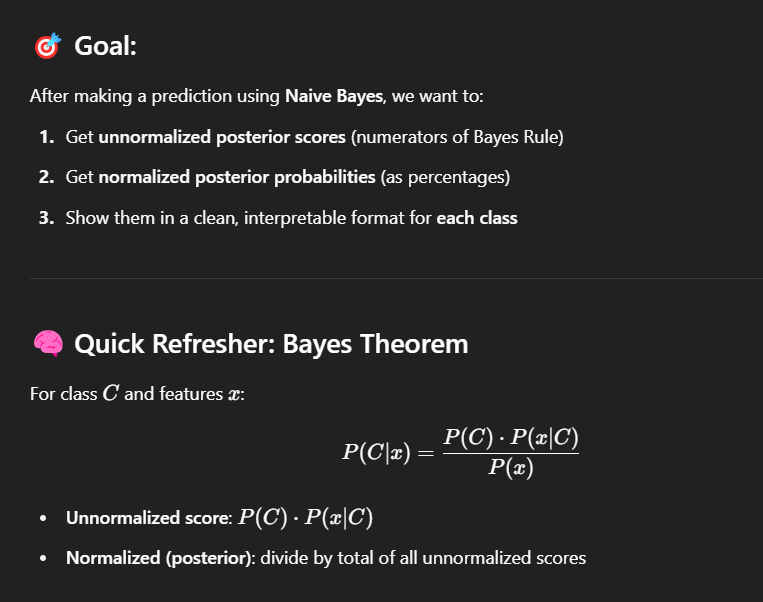

## Predict class probabilities

In [88]:
# Predict probability for each class (normalized)
sample = pd.DataFrame([[2, 1]], columns=['Outlook', 'Temperature'])  # Sunny = 2, Hot = 1
probs = model.predict_proba(sample)
print("Normalized Posterior Probabilities (P(Class|x)):\n", probs)


Normalized Posterior Probabilities (P(Class|x)):
 [[0.52941176 0.47058824]]
